In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, pointbiserialr
from itertools import combinations

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

df = pd.read_csv("/home/onyxia/work/ml-uncertainty-quantification-and-sources/bank-full.csv", sep=';')

Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification. Rappelez-vous que, pour éviter le surapprentissage de nos données, nous devons mettre en place une validation croisée, cependant, nous devons nous assurer qu’au moins les fonctionnalités ayant le plus d’influence sur notre étiquette (qu’un client potentiel ouvre un dépôt à terme ou non) soient réparties équitablement. Que veux-je dire par là ?

1) Nous devons voir comment nos données sont distribuées.
2) Après avoir noté que la colonne « prêt » contient 87 % de « non » (Ne pas de prêts personnels) et 13 % de « oui » (Avoir des prêts personnels).
3) Nous voulons nous assurer que notre ensemble d’entraînement et de test contient le même ratio de 87 % de « non » et 13 % de « oui ». Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification.

Afin de préserver la distribution déséquilibrée de la variable cible, les données ont été séparées en ensembles d’apprentissage et de test à l’aide d’un échantillonnage stratifié basé sur la variable de souscription. Cette approche garantit une représentativité cohérente des classes dans les deux ensembles.

In [6]:
# Echantillonage train-set 

from sklearn.model_selection import StratifiedShuffleSplit

# Définition du split stratifié sur la variable cible
stratified = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Split
for train_idx, test_idx in stratified.split(df, df["y"]):
    stratified_train = df.loc[train_idx]
    stratified_test = df.loc[test_idx]

# Vérification des distributions
print("Distribution globale :")
print(df["y"].value_counts(normalize=True))

print("\nDistribution train :")
print(stratified_train["y"].value_counts(normalize=True))

print("\nDistribution test :")
print(stratified_test["y"].value_counts(normalize=True))


Distribution globale :
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Distribution train :
y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

Distribution test :
y
no     0.883003
yes    0.116997
Name: proportion, dtype: float64


In [9]:
# Encodage des variables
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer


categorical_nominal = [
    "job", "marital", "education",
    "contact", "month", "poutcome"
]

categorical_binary = ["default", "housing", "loan"]

numerical_features = [
    "age", "balance", "day",
    "campaign", "pdays", "previous",
]

#making preprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat_nom", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_nominal),
        ("cat_bin", OneHotEncoder(drop="if_binary"), categorical_binary)
    ]
)


In [14]:
# Séparation X / y
X_train = stratified_train.drop(columns=["y"])
X_test  = stratified_test.drop(columns=["y"])

# Encoder y
le = LabelEncoder()
y_train = le.fit_transform(stratified_train["y"])
y_test  = le.transform(stratified_test["y"])

# Préprocessing
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)



Suite : Maxime

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_transformed, y_train)

y_proba = model.predict_proba(X_test_transformed)[:, 1] #Proba de succès
y_proba[:10]


array([0.01325112, 0.02553587, 0.03577086, 0.01729086, 0.13129165,
       0.04834753, 0.07100212, 0.83871235, 0.11114706, 0.09541112])

In [31]:
def predict_with_threshold(proba, threshold):
    return (proba >= threshold).astype(int) #Renvoie 0 ou 1 selon que la proba dépasse le seuil en argument

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.linspace(0.05, 0.95, 50) #On va tester 90 seuils pour voir celui qui nous semble le plus pertinent

#Voici les métrics qu'on va regarder
precision_list = [] 
recall_list = []
f1_list = []
accuracy_list = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list.append(precision_score(y_test, y_pred_t))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t))
    accuracy_list.append(accuracy_score(y_test, y_pred_t))



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


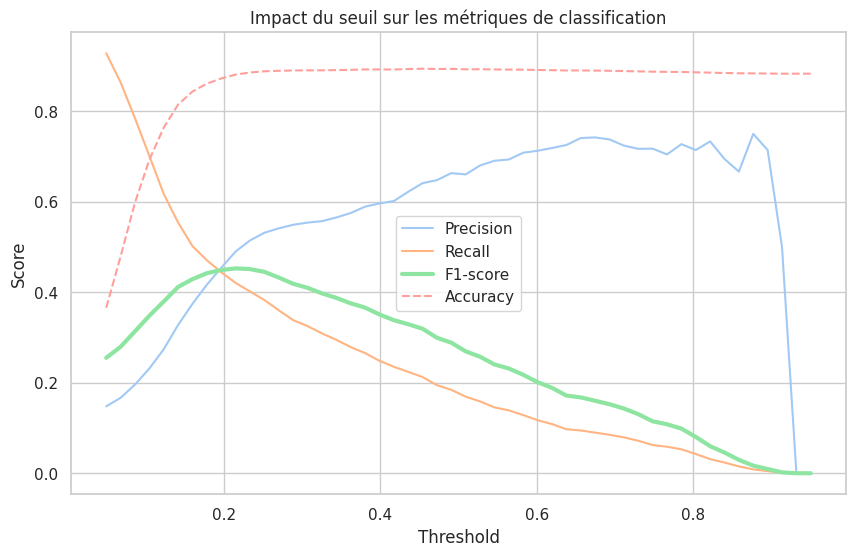

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1-score", linewidth=3)
plt.plot(thresholds, accuracy_list, label="Accuracy", linestyle="--")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impact du seuil sur les métriques de classification")
plt.legend()
plt.grid(True)
plt.show()


In [64]:
best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.21530612244897956)

Il nous semble intéressant de privilégier le F1 score, du fait du fort dédéquilibre de classes


Confusion matrix (threshold = 0.21530612244897956)
[[7522  463]
 [ 613  445]]

Confusion matrix (threshold = 0.5)
[[7891   94]
 [ 871  187]]


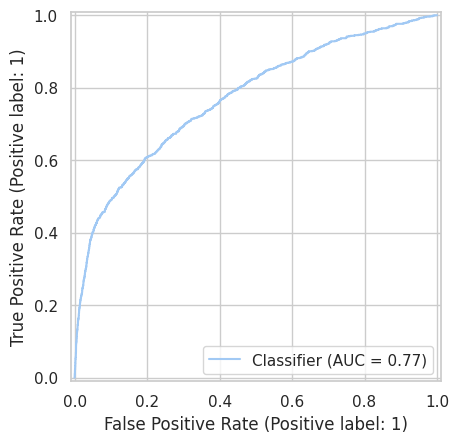

In [65]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

# seuils à tester
for t in [0.21530612244897956, 0.5]: #On teste le seuil qui maximise F1 et le classique 0.5
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    
    print(f"\nConfusion matrix (threshold = {t})")
    print(cm)
RocCurveDisplay.from_predictions(y_test, y_proba)


Le seuil de 0.2 est plus intéressant parce qu'on a pas un coût excessivement élevé au faux-positif.

On va essayer de mettre en place une méthode LDA

In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(store_covariance=True)
lda.fit(X_train_transformed.toarray(), y_train) #On passe au array pour éviter une matrice sparsed


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [52]:
lda.means_

array([[-0.00899172, -0.0200278 ,  0.00967998,  0.02619839, -0.03665372,
        -0.03233819,  0.22729123,  0.03397313,  0.02905721,  0.20258634,
         0.04371106,  0.03447412,  0.09550052,  0.01687698,  0.16923944,
         0.02711588,  0.0064502 ,  0.61326988,  0.27216082,  0.51914707,
         0.2823371 ,  0.04026678,  0.06243542,  0.31183267,  0.13905501,
         0.00294329,  0.05413783,  0.0314682 ,  0.1573097 ,  0.118859  ,
         0.00601184,  0.32323011,  0.08851802,  0.01042678,  0.00773398,
         0.03882644,  0.01333876,  0.84103078,  0.01906879,  0.5832107 ,
         0.16961518],
       [ 0.06787251,  0.15117649, -0.0730677 , -0.19775417,  0.27667452,
         0.24409942,  0.13495628,  0.02387143,  0.02008981,  0.24604113,
         0.09832191,  0.03356181,  0.07043252,  0.05176081,  0.15670054,
         0.03734342,  0.00661782,  0.51642638,  0.36279839,  0.46821082,
         0.37272512,  0.04632475,  0.07634129,  0.10092177,  0.12881116,
         0.01985346,  0.08248

Ceci nous permet de voir la moyenne empirique de chaque predicteur, estimée par classe.

In [44]:
lda.priors_

array([0.88301814, 0.11698186])

On a l'estimation de nos priors

In [45]:
lda.scalings_

array([[ 2.87261373e-03],
       [ 6.00013506e-02],
       [ 3.53976100e-02],
       [-1.11024671e-01],
       [-4.35447920e-02],
       [ 2.82806030e-02],
       [-5.82194468e-02],
       [-1.28929166e-01],
       [-2.69363191e-01],
       [-3.31922225e-02],
       [ 4.54320655e-01],
       [-1.10371625e-01],
       [-5.45668864e-02],
       [ 5.26704698e-01],
       [-4.52542867e-02],
       [ 9.57416964e-02],
       [-1.72611059e-01],
       [-1.61224402e-01],
       [ 7.82940174e-02],
       [ 8.82725225e-02],
       [ 2.20337630e-01],
       [ 8.53715206e-02],
       [-1.65337769e-01],
       [-7.80978509e-01],
       [-8.71022491e-01],
       [ 1.27626334e+00],
       [-3.65653530e-01],
       [-1.04186222e+00],
       [-7.13781260e-01],
       [-9.14318117e-02],
       [ 1.98943622e+00],
       [-4.30026919e-01],
       [-8.45242754e-01],
       [ 1.21187432e+00],
       [ 1.24756759e+00],
       [ 2.62212039e-01],
       [ 3.82498942e+00],
       [ 4.44168931e-02],
       [-1.1

Ceci nous a donné à quelle point chaque variable participe à la frontière (et dans quelle direction)

In [56]:
results=lda.predict(X_test_transformed.toarray())
results_probas=lda.predict_proba(X_test_transformed.toarray())[:,1]

On veut voir le ROC

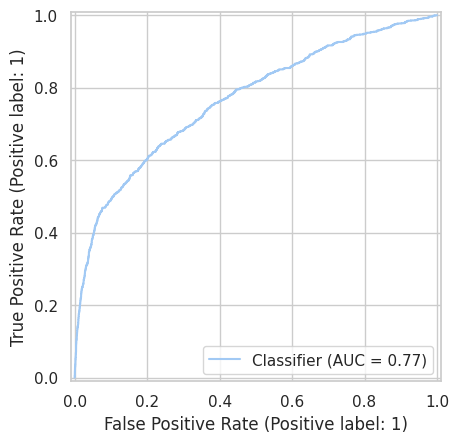

In [57]:
RocCurveDisplay.from_predictions(y_test, results_probas)

In [60]:

#Voici les métrics qu'on va regarder
precision_list_LDA = [] 
recall_list_LDA = []
f1_list_LDA = []
accuracy_list_LDA = []

for t in thresholds:
    results_pred_t = (results_probas >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_LDA.append(precision_score(y_test, results_pred_t))
    recall_list_LDA.append(recall_score(y_test, results_pred_t))
    f1_list_LDA.append(f1_score(y_test, results_pred_t))
    accuracy_list_LDA.append(accuracy_score(y_test, results_pred_t));

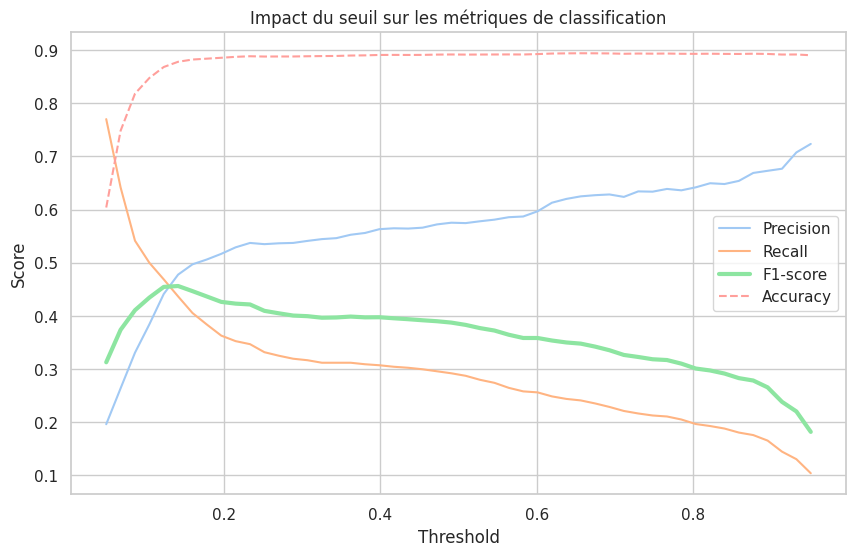

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision_list_LDA, label="Precision")
plt.plot(thresholds, recall_list_LDA, label="Recall")
plt.plot(thresholds, f1_list_LDA, label="F1-score", linewidth=3)
plt.plot(thresholds, accuracy_list_LDA, label="Accuracy", linestyle="--")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impact du seuil sur les métriques de classification")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
best_idx = np.argmax(f1_list_LDA)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.14183673469387753)


Confusion matrix (threshold = 0.14183673469387753)
[[7480  505]
 [ 596  462]]

Confusion matrix (threshold = 0.5)
[[7758  227]
 [ 751  307]]


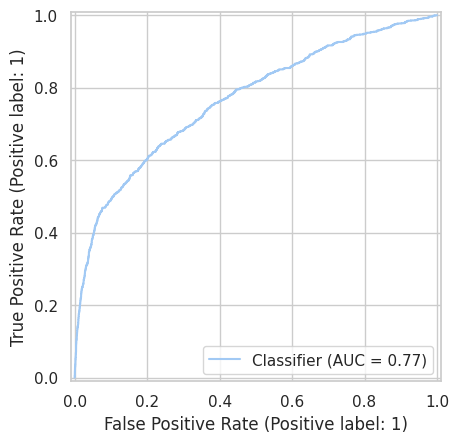

In [67]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

# seuils à tester
for t in [0.14183673469387753, 0.5]: #On teste le seuil qui maximise F1 et le classique 0.5
    results_pred_t = (results_probas >= t).astype(int)
    cm = confusion_matrix(y_test, results_pred_t)

    
    print(f"\nConfusion matrix (threshold = {t})")
    print(cm)
RocCurveDisplay.from_predictions(y_test, results_probas)


QDA

In [68]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

qda = QDA(store_covariance=True)
qda.fit(X_train_transformed.toarray(), y_train) #On passe au array pour éviter une matrice sparsed


,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [69]:
results_qda=qda.predict(X_test_transformed.toarray())
results_probas_qda=qda.predict_proba(X_test_transformed.toarray())[:,1]

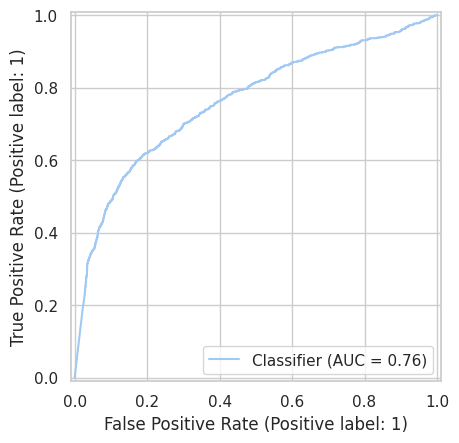

In [70]:
RocCurveDisplay.from_predictions(y_test, results_probas_qda)

In [71]:

#Voici les métrics qu'on va regarder
precision_list_QDA = [] 
recall_list_QDA = []
f1_list_QDA= []
accuracy_list_QDA = []

for t in thresholds:
    results_pred_qda = (results_probas_qda >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_QDA.append(precision_score(y_test, results_pred_qda))
    recall_list_QDA.append(recall_score(y_test, results_pred_qda))
    f1_list_QDA.append(f1_score(y_test, results_pred_qda))
    accuracy_list_QDA.append(accuracy_score(y_test, results_pred_qda));

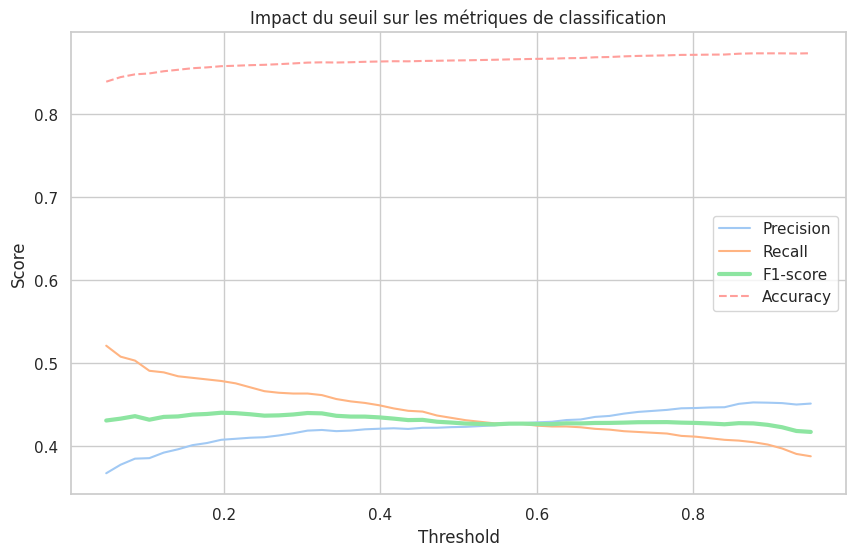

In [72]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision_list_QDA, label="Precision")
plt.plot(thresholds, recall_list_QDA, label="Recall")
plt.plot(thresholds, f1_list_QDA, label="F1-score", linewidth=3)
plt.plot(thresholds, accuracy_list_QDA, label="Accuracy", linestyle="--")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impact du seuil sur les métriques de classification")
plt.legend()
plt.grid(True)
plt.show()

In [73]:
best_idx = np.argmax(f1_list_QDA)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.19693877551020406)


Confusion matrix (threshold = 0.19693877551020406)
[[7249  736]
 [ 552  506]]

Confusion matrix (threshold = 0.5)
[[7359  626]
 [ 600  458]]


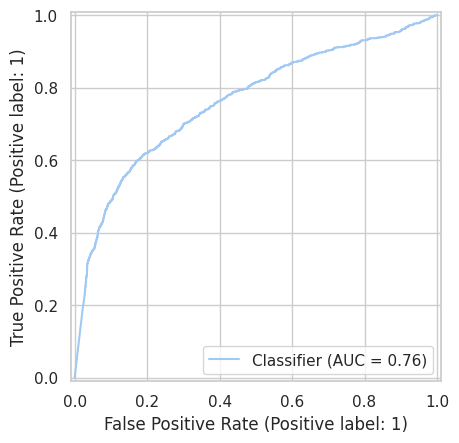

In [74]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

# seuils à tester
for t in [0.19693877551020406, 0.5]: #On teste le seuil qui maximise F1 et le classique 0.5
    results_pred_QDA = (results_probas_qda >= t).astype(int)
    cm = confusion_matrix(y_test, results_pred_QDA)

    
    print(f"\nConfusion matrix (threshold = {t})")
    print(cm)
RocCurveDisplay.from_predictions(y_test, results_probas_qda)